# Dataset

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

# Initialize seed
rng = np.random.default_rng(2026)

# fetch dataset
spambase = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

# metadata
print(spambase.metadata)

# variable information
print(spambase.variables)


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [ ]:
y.head()

,Class
0,1
1,1
2,1
3,1
4,1


In [ ]:
X.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [ ]:
#standarize function
def standardize_fit(X_train):
    """
    Compute mean and std using training data only.
    """
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Avoid division by zero
    std[std == 0] = 1.0

    return mean, std

def standardize_transform(X, mean, std):
    return (X - mean) / std

# Task 1


In [ ]:
"""
i have added two more feature which is not required
1. momentum feature
2. plotting using loss

"""

'\ni have added two more feature which is not required\n1. momentum feature\n2. plotting using loss\n\n'

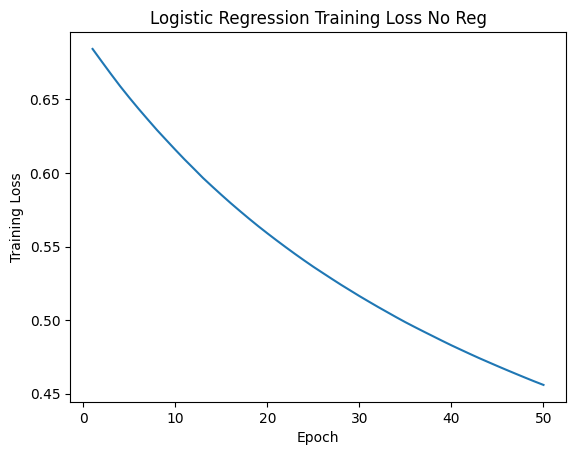

In [ ]:
# building logistic regression with SGD
# we use the recommended hyperparameters
batch_size = 16
lr = 0.001
epochs = 50
lam = 0.001
# momentum factor
use_momentum = True
beta = 0.9
# trackers
loss_history = []
w_history = []
b_history = []

# this is for plotting only, going beyond requirement !!!
def compute_loss(X, y, w, b):
    """
    X: (N,d)
    y: (N,1)
    """
    z = X @ w + b
    y_hat = sigmoid(z)

    # numerical stability to avoid log(0)
    eps = 1e-12
    ce = -np.mean(
        y * np.log(y_hat + eps) +
        (1 - y) * np.log(1 - y_hat + eps)
    )


    return ce

def compute_gradient(X_batch: np.ndarray, y_batch: np.ndarray, w: np.ndarray, b: float, lam: float):
  """
  here we use the l2 in form of  L_reg(w,b) = L(w,b) + lam * ||w||^2
  this means we need to add a 2 lam w in dw that we get

  X_batch: (B,d)
  y_batch: (B,1)
  w: (d,1)
  b: scalar

  returns dw: (d,1) , db: (scaler)
  """
  # batch_size
  B = X_batch.shape[0]
  # logit
  z = X_batch @ w + b
  # prediction
  y_hat = sigmoid(z)
  # error
  err = y_hat - y_batch

  # cross_entropy loss wrt w
  dw = (X_batch.T @ err) / B
  db = float(np.sum(err) / B)

  # L2
  dw += 2.0 * lam * w
  return dw, db


def sigmoid(z: np.ndarray) -> np.ndarray:
  # for numeric stability
  z = np.clip(z, -500, 500)
  return 1.0 / (1.0 + np.exp(-z))


def update_params(w, b, dw, db, lr, use_momentum, vw, vb, beta):
    """
    Momentum (go beyond the required analysis):
      v = beta*v + (1-beta)*grad
      param -= lr*v
    If no momentum (what is only required):
      param -= lr*grad
    """
    if use_momentum:
        vw = beta * vw + (1 - beta) * dw
        vb = beta * vb + (1 - beta) * db
        w = w - lr * vw
        b = b - lr * vb
    else:
        w = w - lr * dw
        b = b - lr * db
    return w, b, vw, vb



# ---------- prepare data ----------
X_np = X.to_numpy(dtype=float)
y_np = y.to_numpy(dtype=float).reshape(-1, 1)

# Split data into training and test sets
indices = rng.permutation(X.shape[0])
train_size = int(0.05 * X.shape[0])
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X_np[train_indices]
y_train = y_np[train_indices]
X_test = X_np[test_indices]
y_test = y_np[test_indices]
# standardize the data using the training set mean and std to avoid leakage
mean, std = standardize_fit(X_train)
X_train = standardize_transform(X_train, mean, std)
X_test  = standardize_transform(X_test,  mean, std)

def train(X_train, y_train, w, b, lam, lr, epochs, batch_size, use_momentum, beta):

    # Init
    n = X_train.shape[0]
    d = X_train.shape[1]
    # vw,vb set to 0 for momentum feature
    vw = np.zeros_like(w)
    vb = 0.0

    for epoch in range(epochs):
        # reshuffle each epoch
        indices = rng.permutation(len(X_train))
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        # seperate into batches
        for start in range(0, len(X_train), batch_size):
            end = min(start + batch_size, len(X_train))
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # now use the batch to do SGD
            dw, db = compute_gradient(X_batch, y_batch, w, b, lam)
            w, b, vw, vb = update_params(w, b, dw, db, lr, use_momentum, vw, vb, beta)

        # append to trackers
        loss_history.append(compute_loss(X_train, y_train, w, b))
        w_history.append(w.copy())
        b_history.append(float(b))

    return w, b

# initialize parameters
n = X.shape[0]
w = np.zeros((X_train.shape[1], 1))
b = 0.0
# we use lam = 0 for non reg
w, b = train(X_train = X_train, y_train = y_train, w = w, b = b, lam = 0, lr = lr, epochs = epochs, batch_size = batch_size, use_momentum = False, beta = beta)
plt.figure()
plt.plot(range(1, epochs+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Logistic Regression Training Loss No Reg")
plt.show()








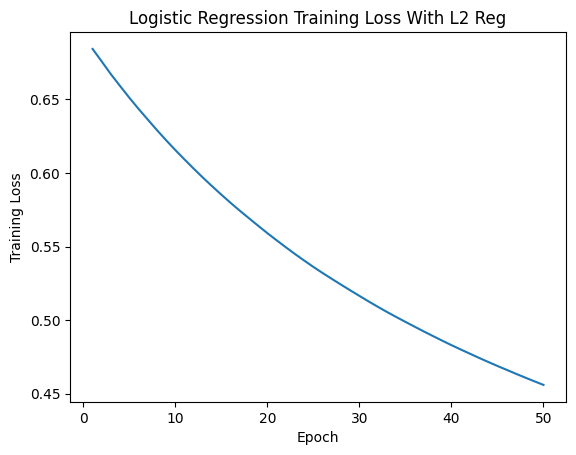

In [ ]:
loss_history = []
w_history = []
b_history = []
w = np.zeros((X_train.shape[1], 1))
b = 0.0
# with L2
w, b = train(X_train = X_train, y_train = y_train, w = w, b = b, lam = lam, lr = lr, epochs = epochs, batch_size = batch_size, use_momentum = False, beta = beta)
plt.figure()
plt.plot(range(1, epochs+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Logistic Regression Training Loss With L2 Reg")
plt.show()


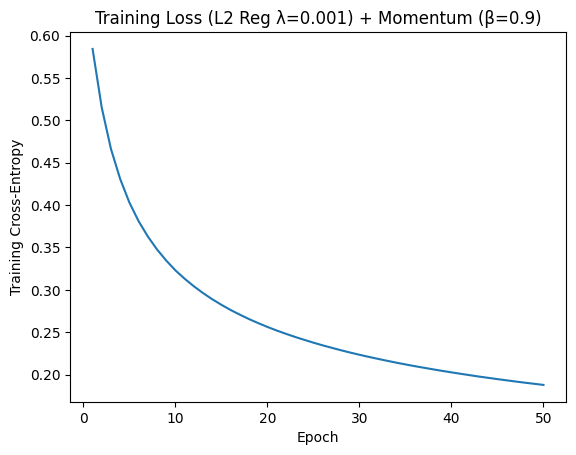

In [ ]:
# ------------------- L2 Regularization + Momentum batch 1-------------------
batch_size = 1
loss_history = []
w_history = []
b_history = []

w = np.zeros((X_train.shape[1], 1))
b = 0.0

w, b = train(
    X_train=X_train, y_train=y_train,
    w=w, b=b,
    lam=lam,
    lr=lr,
    epochs=epochs,
    batch_size=batch_size,
    use_momentum=True,
    beta=beta
)
batch_size = 16
plt.figure()
plt.plot(range(1, epochs+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training Cross-Entropy")
plt.title(f"Training Loss (L2 Reg λ={lam}) + Momentum (β={beta})")
plt.show()


# Task 2

In [ ]:
# Computes binary cross-entropy
def log_loss(y_true, p_pred, eps=1e-12):
    y_true = np.asarray(y_true).reshape(-1)
    p = np.clip(np.asarray(p_pred).reshape(-1), eps, 1 - eps)
    return float(-np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p)))

#thresholding predicted probabilities at 0.5
def accuracy(y_true, p_pred):
    y_true = np.asarray(y_true).reshape(-1)
    p_pred = np.asarray(p_pred).reshape(-1)
    y_hat = (p_pred >= 0.5).astype(int)
    return float(np.mean(y_hat == y_true))

In [ ]:
# Adds a bias (intercept) column of ones to the feature matrix X.
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

# Splits shuffled indices 0..n-1 into k folds (lists of index arrays) for cross-validation.
def fold_indices(n, k, rng):
    fold_size = n // k
    indices = rng.permutation(n)
    folds = []
    for i in range(k - 1):
        folds.append(indices[i * fold_size : (i + 1) * fold_size])
    folds.append(indices[(k - 1) * fold_size :])

    return folds

In [ ]:
# Trains an L2-regularized logistic regression model using mini-batch gradient descent.
def train_logreg_l2_minibatch(Xb, y, lam, lr, batch_size, epochs, rng):

    Xb = np.asarray(Xb, dtype=float)
    y = np.asarray(y).reshape(-1)

    n, p = Xb.shape
    w = np.zeros(p, dtype=float)

    batch_size = int(batch_size)
    epochs = int(epochs)

    for _ in range(epochs):
        perm = rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            Xbatch = Xb[idx]
            ybatch = y[idx]

            pbatch = sigmoid(Xbatch @ w)
            grad = (Xbatch.T @ (pbatch - ybatch)) / len(idx)

            # L2 penalty gradient (exclude bias weight at index 0)
            reg = np.zeros_like(w)
            reg[1:] = 2 * lam * w[1:]

            w -= lr * (grad + reg)

    return w

# Performs K-fold cross-validation to choose the best hyperparameters for logistic regression.
def select_hyperparams(X, y, param_grid, k, seed, metric="logloss"):
    """
    K-fold CV hyperparameter selection.

    - Uses K-fold CV with K >= 3 (and allows K = N)
    - For each hyperparam setting:
        1) Train on K-1 folds
        2) Evaluate on held-out fold
        3) Average metrics across folds
    - Tunes at least: learning rate (lr), batch size, epochs, lam (optional model hyperparameter)
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y).reshape(-1)

    n = X.shape[0]

    rng = np.random.default_rng(seed)
    val_folds = fold_indices(n=n, k=k, rng=rng)

    # Build (train_idx, val_idx) splits
    all_idx = np.arange(n)
    splits = []
    for va_idx in val_folds:
        tr_mask = np.ones(n, dtype=bool)
        tr_mask[va_idx] = False
        splits.append((all_idx[tr_mask], va_idx))

    results = []

    for params in param_grid:
        lr = params["lr"]
        batch_size = params["batch_size"]
        epochs = params["epochs"]
        lam = params.get("lam", 0.0)

        fold_scores = []

        for fold_i, (tr_idx, va_idx) in enumerate(splits):
            Xtr, ytr = X[tr_idx], y[tr_idx]
            Xva, yva = X[va_idx], y[va_idx]

            # Fit preprocessing on TRAIN only
            mu, sigma = standardize_fit(Xtr)
            Xtr_b = add_bias(standardize_transform(Xtr, mu, sigma))
            Xva_b = add_bias(standardize_transform(Xva, mu, sigma))

            # Train
            w = train_logreg_l2_minibatch(
                Xtr_b, ytr,
                lam=lam,
                lr=lr,
                batch_size=batch_size,
                epochs=epochs,
                rng = rng
            )

            # Evaluate
            pva = sigmoid(Xva_b @ w)

            if metric == "logloss":
                score = log_loss(yva, pva)
            elif metric == "accuracy":
                score = accuracy(yva, pva)
            else:
                raise ValueError("metric must be 'logloss' or 'accuracy'")

            fold_scores.append(score)

        mean_score = float(np.mean(fold_scores))
        std_score = float(np.std(fold_scores))
        results.append((mean_score, std_score, params))

    # Sort best-first
    if metric == "logloss":
        results.sort(key=lambda t: t[0])    # lower is better
    else:
        results.sort(key=lambda t: -t[0])   # higher is better

    return results

In [ ]:
K = 5  # at least 3 folds as required

# Small hyperparameter grid (tune: learning rate, batch size, epochs)
param_grid = [
    {"lr": 1e-3, "batch_size": 16, "epochs": 50},
    {"lr": 1e-3, "batch_size": 64, "epochs": 50},
    {"lr": 1e-2, "batch_size": 16, "epochs": 50},
    {"lr": 1e-2, "batch_size": 64, "epochs": 50},
    {"lr": 1e-3, "batch_size": 16, "epochs": 100},
    {"lr": 1e-3, "batch_size": 64, "epochs": 100},
    {"lr": 1e-2, "batch_size": 16, "epochs": 100},
    {"lr": 1e-2, "batch_size": 64, "epochs": 100},
]

# Run K-fold CV and compute BOTH required metrics for every setting
results_logloss = select_hyperparams(X_train, y_train, param_grid=param_grid, k=K, seed=2026, metric="logloss")
results_acc = select_hyperparams(X_train, y_train, param_grid=param_grid, k=K, seed=2026, metric="accuracy")

# Join the two result lists by hyperparameter setting
def _key(params):
    return (params["lr"], int(params["batch_size"]), int(params["epochs"]))

acc_map = {_key(p): (mean, std) for (mean, std, p) in results_acc}

rows = []

# Combine CV logloss results with the matching CV accuracy results into one summary row per hyperparameter setting.
for mean_ll, std_ll, p in results_logloss:
    mean_acc, std_acc = acc_map[_key(p)]
    rows.append({
        "lr": p["lr"],
        "batch_size": int(p["batch_size"]),
        "epochs": int(p["epochs"]),
        "cv_logloss_mean": float(mean_ll),
        "cv_logloss_std": float(std_ll),
        "cv_acc_mean": float(mean_acc),
        "cv_acc_std": float(std_acc),
    })

# Deliverable: a clearly labeled CV results table
rows = sorted(rows, key=lambda r: r["cv_logloss_mean"])  # best-by-logloss first

header = ["rank","lr","batch_size","epochs","cv_logloss_mean","cv_logloss_std","cv_acc_mean","cv_acc_std"]
print(" | ".join(f"{h:>14}" for h in header))
print("-" * (17 * len(header)))
for i, r in enumerate(rows):
    print(" | ".join([
        f"{i+1:14d}",
        f"{r['lr']:14.6g}",
        f"{r['batch_size']:14d}",
        f"{r['epochs']:14d}",
        f"{r['cv_logloss_mean']:14.6f}",
        f"{r['cv_logloss_std']:14.6f}",
        f"{r['cv_acc_mean']:14.6f}",
        f"{r['cv_acc_std']:14.6f}",
    ]))

# Deliverable: pick the best configuration (here: lowest mean CV cross-entropy)
best = rows[0]
print("\nBest hyperparameters (by mean CV cross-entropy):", {k: best[k] for k in ["lr","batch_size","epochs"]})
print(f"Mean CV cross-entropy = {best['cv_logloss_mean']:.6f} (std {best['cv_logloss_std']:.6f})")
print(f"Mean CV accuracy       = {best['cv_acc_mean']:.6f} (std {best['cv_acc_std']:.6f})")


          rank |             lr |     batch_size |         epochs | cv_logloss_mean | cv_logloss_std |    cv_acc_mean |     cv_acc_std
----------------------------------------------------------------------------------------------------------------------------------------
             1 |           0.01 |             16 |            100 |       0.331235 |       0.133961 |       0.900000 |       0.044764
             2 |           0.01 |             16 |             50 |       0.333847 |       0.093062 |       0.900000 |       0.044764
             3 |           0.01 |             64 |            100 |       0.356667 |       0.063004 |       0.908696 |       0.031950
             4 |           0.01 |             64 |             50 |       0.402341 |       0.041140 |       0.908696 |       0.025352
             5 |          0.001 |             16 |            100 |       0.421750 |       0.035693 |       0.913043 |       0.030744
             6 |          0.001 |             16 |        

# Task 3

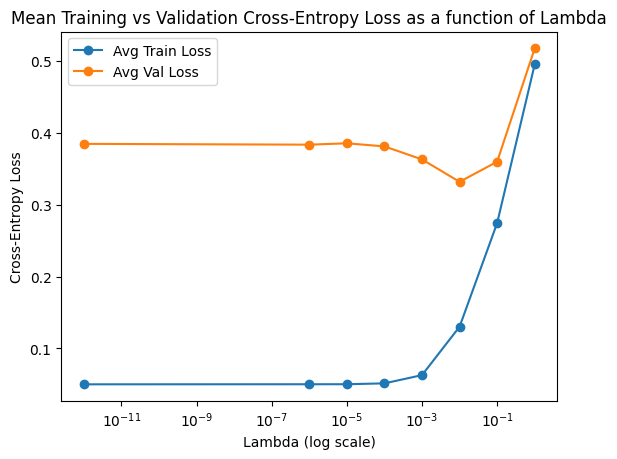

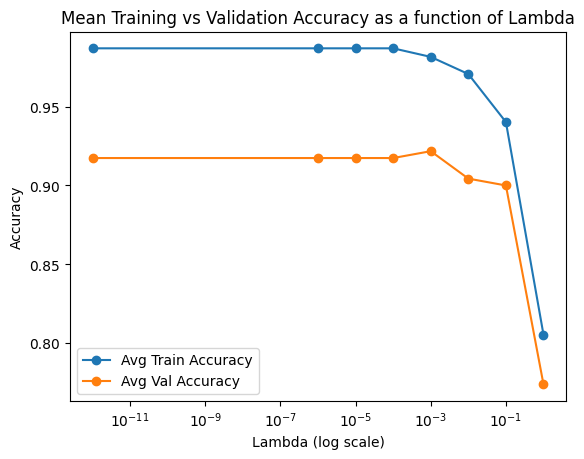

Best lambda: 0.01
Final Test Cross-Entropy Loss: 0.3274
Final Test Accuracy: 0.8998


In [ ]:
'''
N = X.shape[0]
idx = rng.permutation(N)
n_train = int(round(0.05 * N))
train_idx = idx[:n_train]
test_idx  = idx[n_train:]

X_train_raw, y_train = X[train_idx], y[train_idx]
X_test_raw,  y_test  = X[test_idx],  y[test_idx]
'''

#Fixed hyperparameters
learning_rate = 0.1
batch_size = 16
num_epochs = 200
lambda_grid = [0, 10**-6, 10**-5, 10**-4, 10**-3, 10**-2, 10**-1, 1]

# ----- Task 3 Functions -----

# K-fold CV function
def k_fold_CV(x, y, folds, lam, learning_rate=0.1, num_epochs=200, batch_size=16):
    '''
    Inputs: x: training data, y: training labels, folds: folds, lambda: regularization strength
    Outputs: average training cross-entropy loss, average validation cross-entropy loss, average training accuracy, average validation accuracy
    '''

    # Initialize results lists
    training_cross_entropy_losses = []
    validation_cross_entropy_losses = []
    training_accuracies = []
    validation_accuracies = []

    # K-fold cross-validation
    for i in range(len(folds)):

        # Create training and validation sets
        validation_indices = folds[i]
        training_indices = []
        for j in range(len(folds)):
            if j != i:
                training_indices.extend(folds[j])
        x_train, y_train = x[training_indices], y[training_indices]
        x_val, y_val = x[validation_indices], y[validation_indices]

        # Standardize
        mu, sigma = standardize_fit(x_train)
        x_train = standardize_transform(x_train, mu, sigma)
        x_val = standardize_transform(x_val, mu, sigma)

        # Train the model
        d = x_train.shape[1]
        w, b = np.zeros((d, 1)), 0.0
        w, b = train(X_train=x_train, y_train=y_train, w=w, b=b, lam=lam, lr=learning_rate, epochs=num_epochs, batch_size=batch_size, use_momentum=False, beta=0.9)

        # Validate the model
        y_train_pred = sigmoid(x_train @ w + b)
        y_val_pred = sigmoid(x_val @ w + b)
        training_cross_entropy_losses.append(cross_entropy_loss(y_train, y_train_pred))
        validation_cross_entropy_losses.append(cross_entropy_loss(y_val, y_val_pred))
        training_accuracies.append(get_accuracy(y_train, y_train_pred))
        validation_accuracies.append(get_accuracy(y_val, y_val_pred))

    return np.mean(training_cross_entropy_losses), np.mean(validation_cross_entropy_losses), np.mean(training_accuracies), np.mean(validation_accuracies)

# Cross-entropy loss function
def cross_entropy_loss(y_true, y_pred):
    eps = 1e-12
    return np.mean(-y_true * np.log(y_pred + eps) - (1 - y_true) * np.log(1 - y_pred + eps))

# Accuracy function
def get_accuracy(y_true, y_pred):
    y_pred_labels = (y_pred >= 0.5).astype(int)
    return np.mean(y_true == y_pred_labels)

# Running k-fold for each lambda
results = []
nb_folds = 5
folds = fold_indices(X_train.shape[0], nb_folds, rng)
for lam in lambda_grid:
    avg_train_loss, avg_val_loss, avg_train_acc, avg_val_acc = k_fold_CV(x = X_train, y = y_train, folds = folds, lam = lam)
    results.append((lam, avg_train_loss, avg_val_loss, avg_train_acc, avg_val_acc))

# Plot mean training vs validation cross-entropy as a function of lambda
lambda_grid_non_zero = [1e-12, 10**-6, 10**-5, 10**-4, 10**-3, 10**-2, 10**-1, 1]
train_losses = []
val_losses = []
for r in results:
    train_losses.append(r[1])
    val_losses.append(r[2])
plt.figure()
plt.plot(lambda_grid_non_zero, train_losses, label='Avg Train Loss', marker='o')
plt.plot(lambda_grid_non_zero, val_losses, label='Avg Val Loss', marker='o')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Cross-Entropy Loss')
plt.title('Mean Training vs Validation Cross-Entropy Loss as a function of Lambda')
plt.legend()
plt.show()

# Plot mean training vs validation accuracy as a function of lambda
train_accs = []
val_accs = []
for r in results:
    train_accs.append(r[3])
    val_accs.append(r[4])
plt.figure()
plt.plot(lambda_grid_non_zero, train_accs, label='Avg Train Accuracy', marker='o')
plt.plot(lambda_grid_non_zero, val_accs, label='Avg Val Accuracy', marker='o')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Accuracy')
plt.title('Mean Training vs Validation Accuracy as a function of Lambda')
plt.legend()
plt.show()

# Choosing the best lambda based on validation loss
best_lambda = lambda_grid[np.argmin(val_losses)]
print(f"Best lambda: {best_lambda}")

# Retraining the model on the entire dataset with the best lambda
d = X_train.shape[1]
w, b = np.zeros((d, 1)), 0.0

# Standardize
mu, sigma = standardize_fit(X_train)
X_train = standardize_transform(X_train, mu, sigma)
X_test = standardize_transform(X_test, mu, sigma)

w_final, b_final = train(X_train=X_train, y_train=y_train, w=w, b=b, lam=best_lambda, lr=learning_rate, epochs=num_epochs, batch_size=batch_size, use_momentum=False, beta=0.9)

# Report final performance on the held-out test set
y_test_pred = sigmoid(X_test @ w_final + b_final)
test_cross_entropy_loss = cross_entropy_loss(y_test, y_test_pred)
test_accuracy = get_accuracy(y_test, y_test_pred)
print(f"Final Test Cross-Entropy Loss: {test_cross_entropy_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")


# Task 4

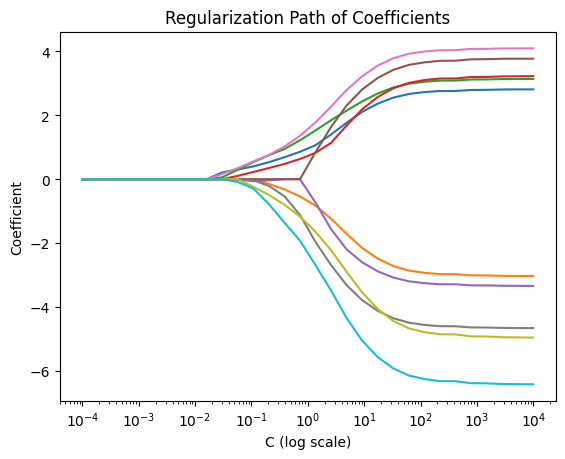

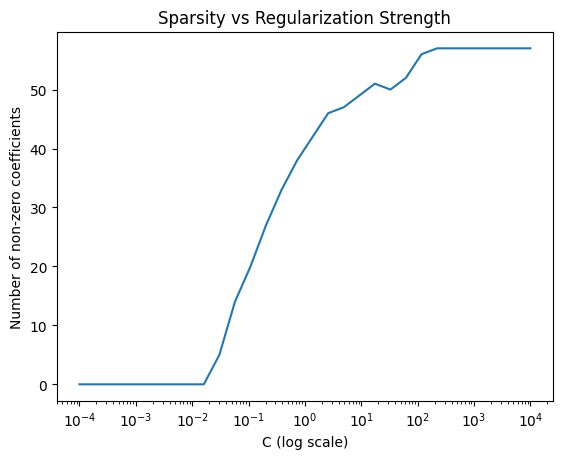

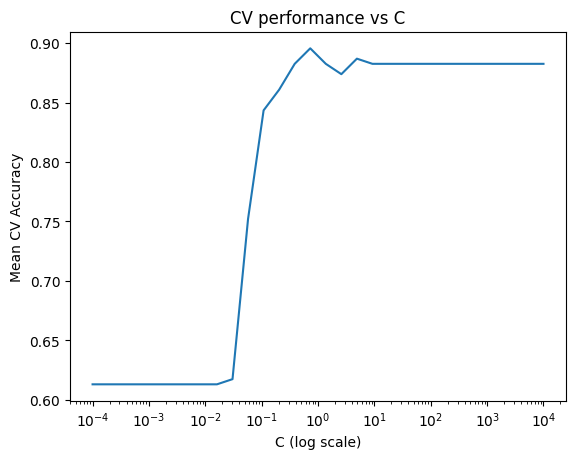

In [ ]:
# ----- Task 4 -----

# Initialize variables
Cs = np.logspace(-4, 4, 30)
coefficients = []
nb_non_zero_coefficients = []
y_train = np.squeeze(y_train)

# Initialize model
model = LogisticRegression(penalty='l1', solver='saga', max_iter=20000, warm_start=True)

for c in Cs:
    # Train model
    model.C = c
    model.fit(X_train, y_train)

    w = model.coef_[0]
    coefficients.append(w)
    nb_non_zero_coefficients.append(np.count_nonzero(w))

coefficients = np.array(coefficients)
nb_non_zero_coefficients = np.array(nb_non_zero_coefficients)

# 1: Plot regularization path of coefficients
k = 10
abs_coefficients = np.abs(coefficients)
top_k_coefficients = np.argsort(np.max(abs_coefficients, axis = 0))[-k:]

plt.figure()
for i in top_k_coefficients:
  plt.plot(Cs, coefficients[: , i])
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Coefficient')
plt.title("Regularization Path of Coefficients")
plt.show()

# 2: Sparsity plot
plt.figure()
plt.plot(Cs, nb_non_zero_coefficients)
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Number of non-zero coefficients')
plt.title("Sparsity vs Regularization Strength")
plt.show()

# 3: CV performance vs C
cv_model = LogisticRegressionCV(penalty='l1', solver='saga', max_iter=20000, Cs=Cs, cv=5, scoring='accuracy')
cv_model.fit(X_train, y_train)
scores = list(cv_model.scores_.values())[0]
mean_cv = scores.mean(axis=0)

plt.figure()
plt.plot(Cs, mean_cv)
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Mean CV Accuracy')
plt.title('CV performance vs C')
plt.show()